uni_section_v17: command_v17.md 반영 (idea_v17.md 5개 판정 구현)
  - 후보군 축소: CANDIDATE_PARTS=[3,4](Patch1/2), S_PROTECT=[0,1,2](Inner Hat도 보호)
  - Mp err 게이팅된 희소화(w_sparse_effective) + 엔트로피 정규화(gate_active 구간)
  - 더블쇼크 분리: 두께언락@10 vs 게이트활성@11
  - State-Only Reset: DELETED 확정 시 optimizer 재인스턴스화 + ALDA mu 리셋 + 20epoch 쿨다운(완전 리셋은 기각됨)

데이터: nodes=torch.Size([93, 8]) | edges=torch.Size([2, 176])

[초기 형상 정보] (학습 시작 전 baseline)
  단면적(질량 proxy) :     1157.3 mm²
    part0:    482.9 mm²
    part1:    315.5 mm²
    part2:    246.9 mm²
    part3:     94.4 mm²
    part4:     17.7 mm²
  Mp(초기 형상)      :     24,678,652 N·mm
  y_pna(초기 형상)   :      32.81 mm
[gradcheck] dMp/dt OK -- autograd=1.3173e+07, FD=1.3160e+07, rel_err=9.88e-04, dMp/dt>0 확인
[mass] target_area = 1157.3 mm² (초기 단면적 스냅샷)
[collision v5] 전쌍(9쌍) 부호 앵커 & clearance (초기 형상 기준):
    sec0 Part0-Part1: 0seg/1pt σ=+1 clr=-0.05 | 1seg/0pt σ=-1 clr=-0.05
    sec0 Part0-Part2: 0seg/2pt σ=+1 clr=0.50
    sec0 Part0-Part3: 0seg/3pt σ=+1 clr=0.50 | 3seg

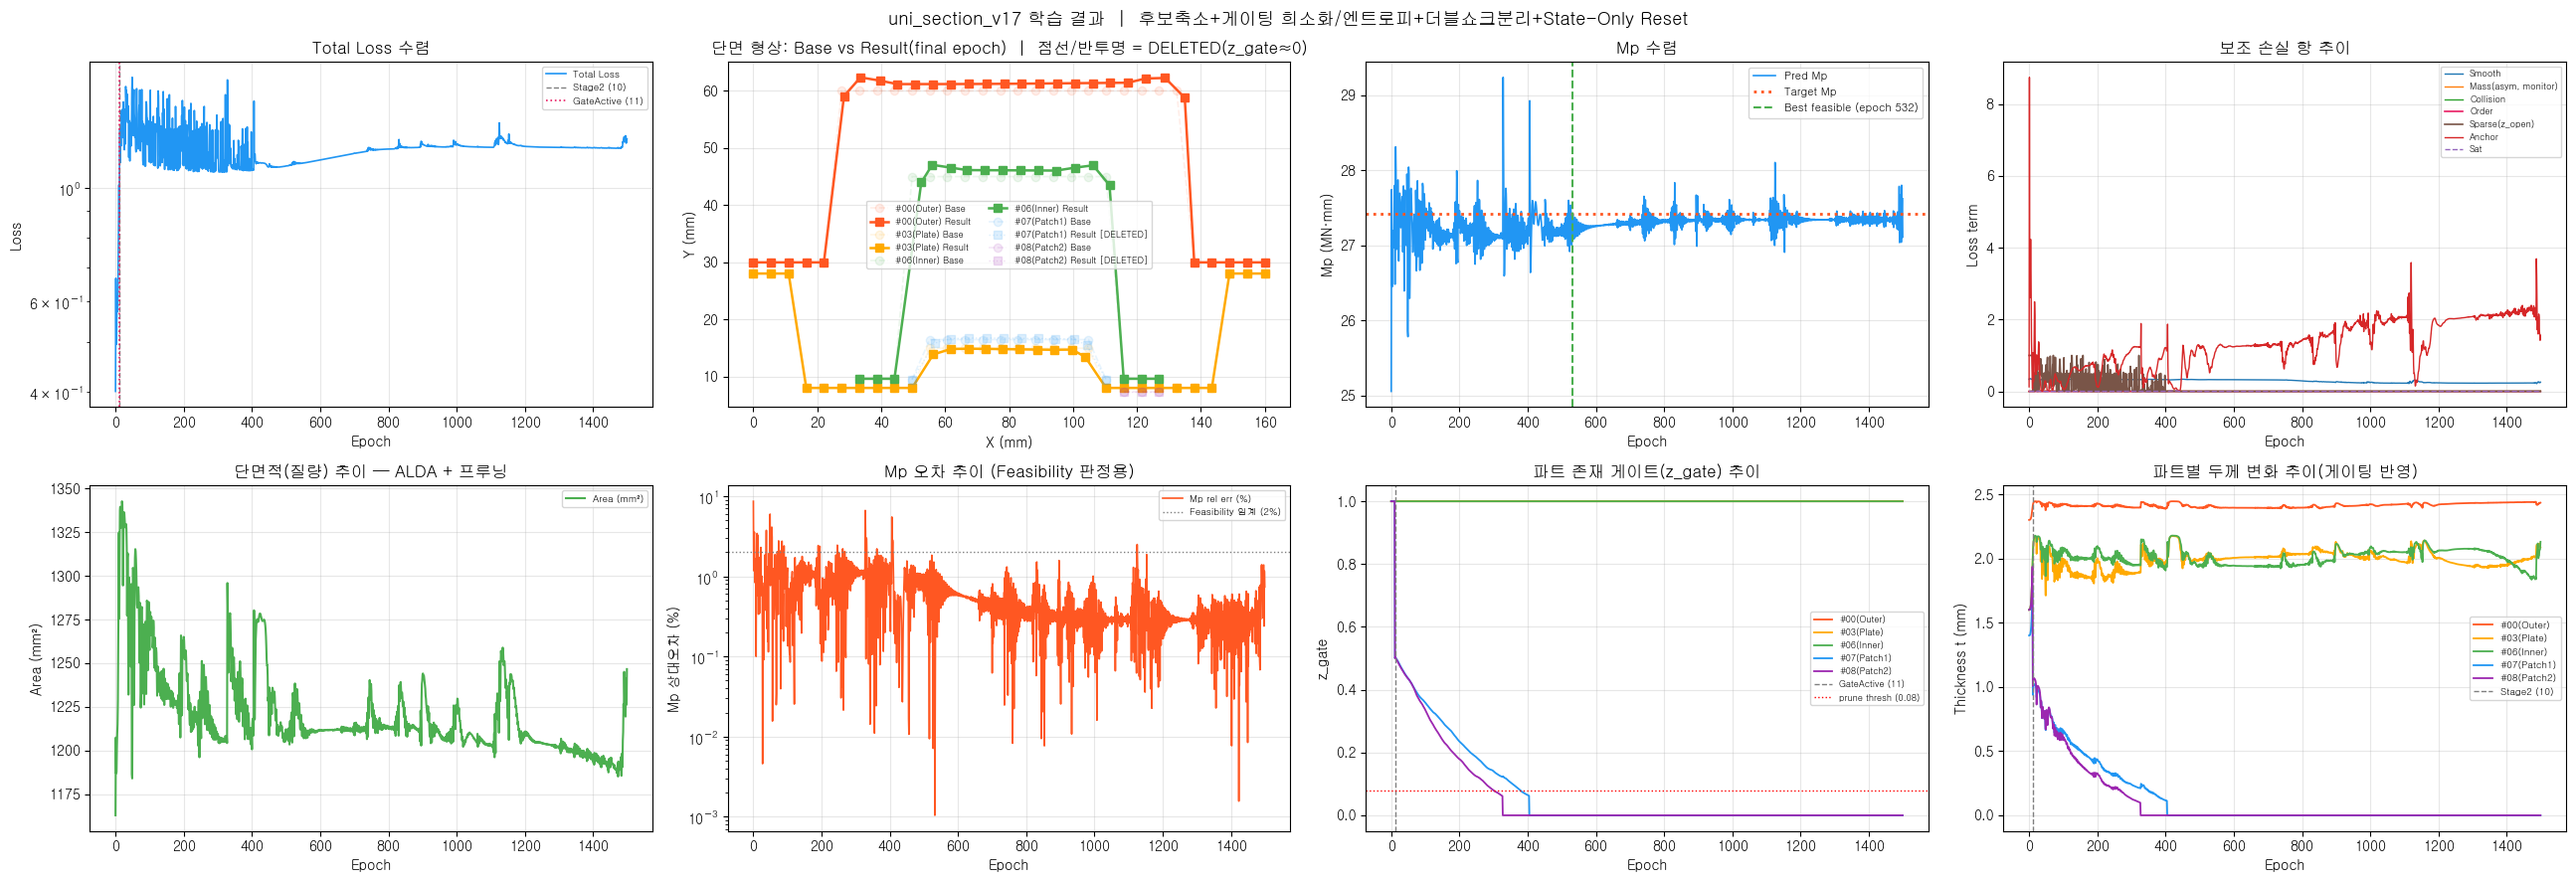


결과 저장: c:\Users\user\Documents\GitHub\hmc_mlv\CGNN\uni-section\code\uni_section_v17_result.png


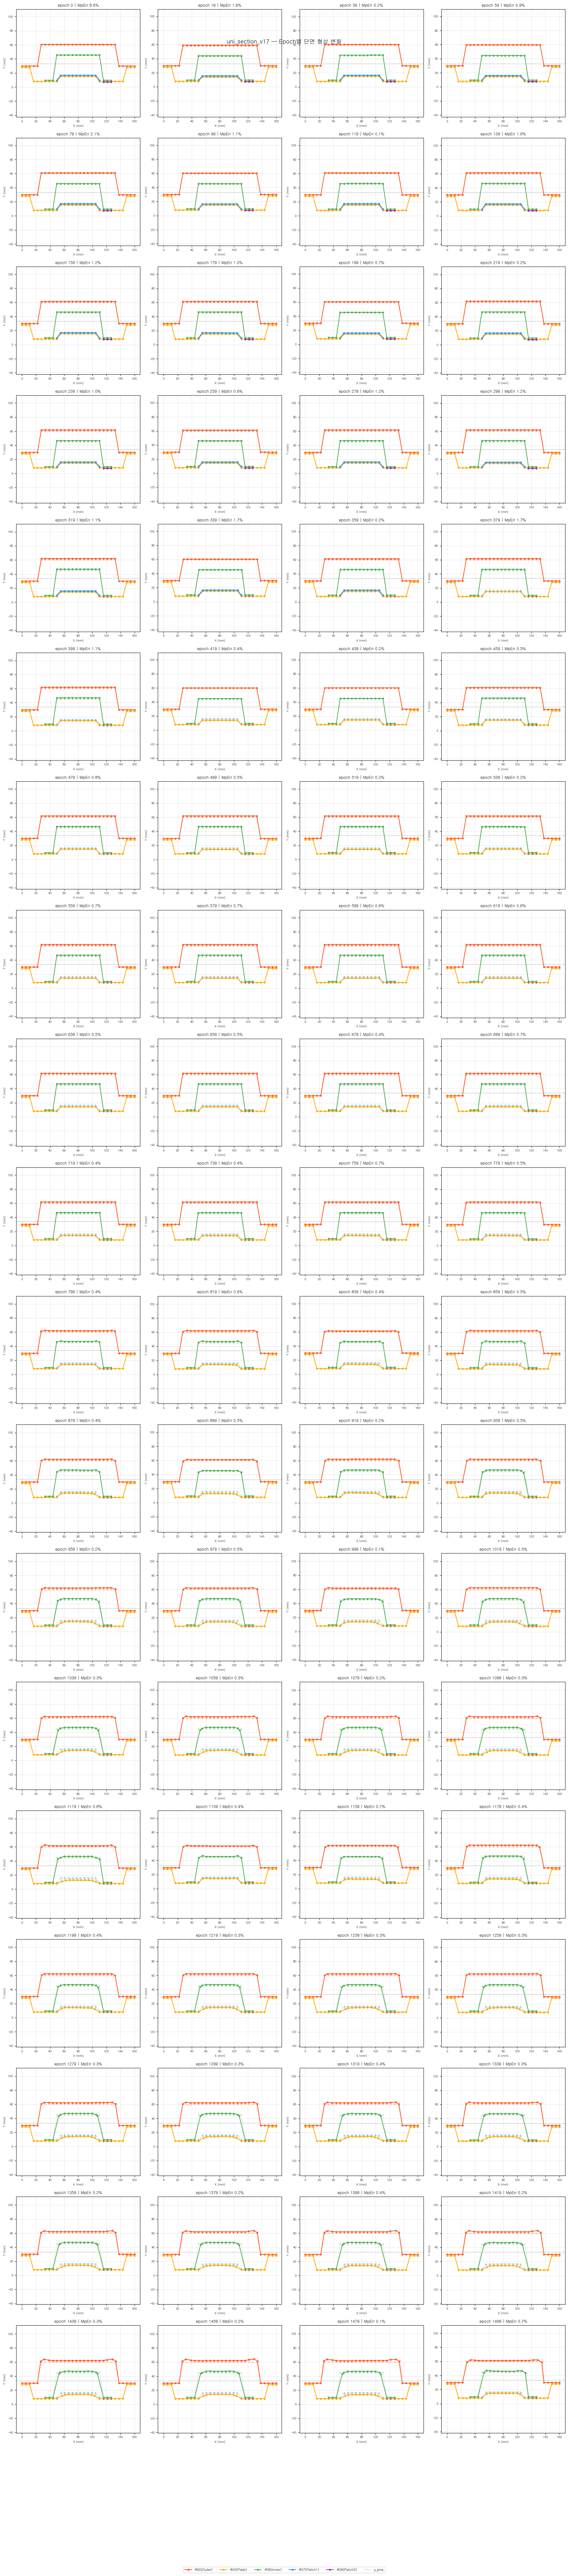


Epoch 스냅샷 결과 저장: c:\Users\user\Documents\GitHub\hmc_mlv\CGNN\uni-section\code\uni_section_v17_epoch_snapshots.png

최종 결과 요약 (마지막 epoch 기준)
  Target Mp     :     27,421,470 N·mm
  Final pred_mp :     27,623,512 N·mm
  Final Error   :   0.74%
  Final l_collision : 0.0061
  Final l_order : 0.0000
  Initial area  :   1157.3 mm²
  Final area    :   1246.6 mm²  (+7.7% vs 초기)
  ALDA mu_Mp/mu_col (final) : 7.94e-01 / 0.00e+00
  Pruning 최종 상태: ['ALIVE', 'ALIVE', 'ALIVE', 'DELETED', 'DELETED']
  ★ 프루닝된 파트: [3, 4] (v16이 달성 못한 실제 트리거 발동)

  ★ Feasible 모델(물리 제약 + Mp 동시 만족) 발견: epoch 532, Mp err=0.00%, l_collision=0.0051
    (best_feasible['state_dict']를 model.load_state_dict()로, best_feasible['pruning_state']를 함께 복원해 사용 권장)


In [18]:
"""
uni_section_v17.py
─────────────────────────────────────
uni_section_v16.py를 docs/command/command_v17.md 지시 사항에 따라 재작성한 버전.
설계 근거: /synod idea 세션(idea_v17.md, v16 실측 로그의 "프루닝 미발동"/"더블쇼크" 문제에 대한 5개
          대응 아이디어 평가, conf 95/85 수렴) → /synod idea 세션(command_v17.md, 구현 지시서, conf
          95(can_exit=true)/85(can_exit=false), 옵티마이저 재구성 방식 쟁점은 Judge가 PyTorch AdamW
          state 동작 원리로 해소) → /synod design 세션(gate_params lr 타이밍/삽입 순서, conf 98/92,
          조기 합의 — OpenAI가 AdamW decoupled weight-decay가 그래디언트 없이도 매 스텝 적용된다는
          점을 근거로 gate_params lr 활성화 시점을 GATE_ACTIVE_EPOCH로 이동해야 함을 지적)

v16 실측 문제(results_v16/uni_section_v16.md) 및 대응:
  (A) 프루닝 트리거 단 한 번도 미발동(ewma_z 최종 0.95~0.97, 임계값 0.08 근처도 못 감)
      → 후보군 축소(Patch1/Patch2만) + Mp err 게이팅된 희소화 강화 + 엔트로피 정규화
  (B) epoch100(Stage2, 두께언락+게이트활성 동시발동) 직후 더블쇼크(MpErr 1.3%→16.9% 급등)
      → GATE_ACTIVE_EPOCH를 STAGE2_EPOCH와 분리(두께가 먼저 안정된 뒤 게이트 활성화)
  (신규) 부재 삭제 시 옵티마이저 모멘텀/ALDA 승수 오염 → State-Only Reset(가중치는 보존)

command_v17.md 반영 사항:
  §1 CANDIDATE_PARTS=[3,4](Patch1,Patch2만), S_PROTECT=[0,1,2](Inner Hat도 보호) — idea_v17.md #1
  §2 GATE_ACTIVE_EPOCH = STAGE2_EPOCH + 30 — 두께 언락과 게이트/프루닝 활성화 시점 분리 — idea_v17.md #4
     design 세션 결론: gate_params optimizer lr 전환도 STAGE2_EPOCH가 아니라 GATE_ACTIVE_EPOCH에서
     수행(AdamW decoupled weight-decay가 gradient 없이도 매 스텝 log_alpha를 감쇠시켜 "휴면 30epoch"
     동안 log_alpha가 의도치 않게 드리프트하는 것을 방지).
  §3 희소화 게이팅 + 엔트로피 정규화 — idea_v17.md #2, #3
     w_sparse_effective = w_sparse * sigmoid(SPARSE_K*(TAU_GATE - mp_rel_err))
     H(z) = -mean(z*log(z+eps) + (1-z)*log(1-z+eps)), gate_active 구간에서만 + 동일 gate_multiplier로
     추가 감쇠(entropy·sparsity 동시 과다 작동으로 인한 재고착 방지, command_v13.md §3 계열 리스크 완화)
     삽입 위치: train_step 내 mp_rel_err 계산 직후(design 세션 합의 — 의존성 확보 후 다른 항보다 먼저 배치)
  §4 State-Only Reset — idea_v17.md #5 (완전 리셋은 명시적으로 기각)
     DELETED 확정 시: (a) 새 AdamW 인스턴스 생성(현재 param_groups의 lr을 동적으로 읽어와 보존 —
     param_groups의 'params' 리스트만 재대입하는 방식은 optimizer.state가 그대로 남아 모멘텀이
     flush되지 않으므로 명시적으로 금지), (b) ALDA mu_Mp/mu_col을 1.0으로 리셋(rho는 유지),
     (c) PRUNING_COOLDOWN_EPOCHS(20) 동안 프루닝 트리거 판정 자체를 skip.
     재구성된 optimizer는 다음 epoch의 train_step부터 자연스럽게 적용됨(추가 조치 불필요, design 세션 확인).

v16과 동일하게 유지되는 부분(이번 범위 밖):
  - ALDA(area objective, Mp/collision 하드제약), collision v5 기하, mesh order loss, 2단계 두께 게이트
    스케줄(STAGE2_EPOCH=128 자체는 불변), 커리큘럼, native autograd Mp, 시각화 함수 골격
  - Cascade 그래프수술(A-5, 실제 노드/엣지 삭제)은 여전히 도입하지 않음 — Soft-Zeroing 유지

리스크(command_v17.md §6, 이번 범위에 특화):
  R-1 옵티마이저 재구성 시 lr 하드코딩 금지 → 매번 optimizer.param_groups에서 동적으로 읽어와 보존
  R-2 엔트로피-희소화 상쇄 → 동일 gate_multiplier 공유로 완화(이미 내장)
  R-3 쿨다운 중 ewma_z 갱신 정지(update_pruning_state 호출 자체를 skip, 의도된 동작)
  R-4 GATE_ACTIVE_EPOCH+쿨다운이 학습 후반에 몰려 실질 프루닝 판정 기간이 짧아질 가능성 → 후보 2개 기준
      여유 있음(관찰 대상)
  R-5 weight_decay는 run_training의 원본 인자와 동일값(1e-4)으로 재구성 시에도 고정
"""

import math
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Gulim'  # Windows 한글 폰트

from torch_geometric.nn import GATv2Conv, LayerNorm
from torch_geometric.data import Data


# ══════════════════════════════════════════════════════════════════
# SECTION 0: Mp 계산 — native autograd (v8/v10/v15/v16 §3.1 유지)
# ══════════════════════════════════════════════════════════════════

def compute_edge_mp_pna(coords, t, fy, edge_index, n_iter=50):
    """Thick Edge (2D Plate) PNA 이분탐색 + Mp 계산 (v16 그대로). Returns: (mp_total, y_pna)"""
    mask = edge_index[0] < edge_index[1]
    u, v = edge_index[0][mask], edge_index[1][mask]

    y_u, y_v = coords[u, 1], coords[v, 1]
    x_u, x_v = coords[u, 0], coords[v, 0]
    L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
    t_e  = t[u].squeeze(-1)
    fy_e = fy[u].squeeze(-1)

    dx   = torch.abs(x_u - x_v)
    t_y  = t_e * (dx / (L + 1e-12))
    y_max = torch.maximum(y_u, y_v)
    y_min = torch.minimum(y_u, y_v)
    y_top = y_max + t_y / 2.0
    y_bot = y_min - t_y / 2.0
    H     = torch.clamp(y_top - y_bot, min=1e-12)

    Area_fy = L * t_e * fy_e

    with torch.no_grad():
        y_lo = coords[:, 1].min().clone() - 5.0
        y_hi = coords[:, 1].max().clone() + 5.0
        for _ in range(n_iter):
            y_mid = 0.5 * (y_lo + y_hi)
            alpha = torch.clamp((y_top - y_mid) / H, 0.0, 1.0)
            net_force = torch.sum(Area_fy * (2.0 * alpha - 1.0))
            if net_force > 0:
                y_lo = y_mid
            else:
                y_hi = y_mid
        y_pna = 0.5 * (y_lo + y_hi)

    alpha        = torch.clamp((y_top - y_pna) / H, 0.0, 1.0)
    centroid_top = y_top - (alpha * H) / 2.0
    centroid_bot = y_bot + ((1.0 - alpha) * H) / 2.0
    m_top        = alpha * (centroid_top - y_pna)
    m_bot        = (1.0 - alpha) * (y_pna - centroid_bot)
    mp_total     = torch.sum(Area_fy * (m_top + m_bot))

    return mp_total, y_pna


def calculate_mpl(coords, t, fy, edge_index):
    mp_total, _ = compute_edge_mp_pna(coords, t, fy, edge_index)
    return mp_total


def verify_thickness_gradient(coords, t, fy, edge_index, eps=1e-4):
    """[v8/v10/v15/v16 §3.1 유지] 학습 전 유한차분으로 ∂Mp/∂t 검증 — 실패 시 학습 중단."""
    coords = coords.detach()
    fy = fy.detach()

    t_leaf = t.detach().clone().requires_grad_(True)
    mp, _ = compute_edge_mp_pna(coords, t_leaf, fy, edge_index)
    mp.backward()
    if t_leaf.grad is None:
        raise RuntimeError("[gradcheck] dMp/dt 가 None!")
    grad_sum = t_leaf.grad.sum().item()

    with torch.no_grad():
        mp_p, _ = compute_edge_mp_pna(coords, t + eps, fy, edge_index)
        mp_m, _ = compute_edge_mp_pna(coords, t - eps, fy, edge_index)
    fd = (mp_p.item() - mp_m.item()) / (2.0 * eps)

    rel_err = abs(fd - grad_sum) / (abs(fd) + 1e-8)
    if fd <= 0:
        raise RuntimeError(f"[gradcheck] dMp/dt = {fd:.4e} <= 0 -- 물리적으로 비정상!")
    if rel_err > 1e-3:
        raise RuntimeError(f"[gradcheck] autograd({grad_sum:.6e}) vs FD({fd:.6e}) "
                           f"상대오차 {rel_err:.2e} > 1e-3")
    print(f"[gradcheck] dMp/dt OK -- autograd={grad_sum:.4e}, FD={fd:.4e}, "
          f"rel_err={rel_err:.2e}, dMp/dt>0 확인")
    return grad_sum, fd, rel_err


class FiLMGenerator(nn.Module):
    """target_mp [B, 1] → (gamma, beta) [B, hidden] (v16 그대로)"""
    MP_SCALE = 1e6

    def __init__(self, hidden_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.GELU(),
            nn.Linear(64, hidden_channels * 2),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, target_mp):
        target_mp_norm = target_mp / self.MP_SCALE
        out = self.net(target_mp_norm)
        delta_gamma, beta = torch.chunk(out, 2, dim=-1)
        gamma = 1.0 + delta_gamma
        return gamma, beta


class CGDNBlock(nn.Module):
    """GATv2Conv → LayerNorm → FiLM → GELU → Residual (v16 그대로)"""
    def __init__(self, hidden_channels: int, heads: int = 4, edge_dim: int = 4):
        super().__init__()
        assert hidden_channels % heads == 0
        self.conv = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads,
            edge_dim=edge_dim,
            concat=True,
        )
        self.norm = LayerNorm(hidden_channels)

    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)
        h = self.norm(h)
        h = gamma * h + beta
        h = F.gelu(h)
        h = h + h_res
        return h


# ══════════════════════════════════════════════════════════════════
# [command_v16.md §1 유지] 파트 존재 게이트 — 이원화(z_gate/z_open)
# ══════════════════════════════════════════════════════════════════

S_PROTECT = [0, 1, 2]        # [command_v17.md §1] Inner Hat(#06, part_id=2) 추가 보호
CANDIDATE_PARTS = [3, 4]     # [command_v17.md §1] Patch1(#07), Patch2(#08)만 후보


def compute_gates(log_alpha, training=True, temperature=0.5, gamma=-0.1, zeta=1.1, s_protect=None):
    """[v16 §1 그대로] HardConcrete relaxation, 게이트 이원화."""
    s_det = torch.sigmoid(log_alpha)
    z_gate = torch.clamp(s_det * (zeta - gamma) + gamma, 0.0, 1.0)

    if training:
        u = torch.rand_like(log_alpha).clamp(1e-6, 1 - 1e-6)
        logistic_noise = torch.log(u) - torch.log(1.0 - u)
        s_stoch = torch.sigmoid((log_alpha + logistic_noise) / temperature)
        z_open = torch.clamp(s_stoch * (zeta - gamma) + gamma, 0.0, 1.0)
    else:
        z_open = z_gate

    if s_protect:
        idx = torch.tensor(s_protect, dtype=torch.long, device=log_alpha.device)
        z_gate = z_gate.clone()
        z_open = z_open.clone()
        z_gate[idx] = 1.0
        z_open[idx] = 1.0

    return z_gate, z_open


def make_pruning_state(num_parts=5, candidate_parts=None):
    """[v16 §3 유지 + command_v17.md §4] EWMA+히스테리시스 프루닝 상태 + 쿨다운 카운터."""
    if candidate_parts is None:
        candidate_parts = CANDIDATE_PARTS
    return {
        'ewma_z': torch.ones(num_parts),
        'state': ['ALIVE'] * num_parts,          # 'ALIVE' | 'PENDING_DELETE' | 'DELETED'
        'pending_duration': torch.zeros(num_parts),
        'ewma_alpha': 0.15,
        'thresh_low': 0.08,
        'thresh_high': 0.15,
        'confirm_epochs': 20,
        's_protect': S_PROTECT,
        'candidate_parts': candidate_parts,
        'cooldown_remaining': 0,   # [command_v17.md §4] State-Only Reset 이후 쿨다운
    }


@torch.no_grad()
def update_pruning_state(pruning_state, z_gate_per_part):
    """[v16 §3.2 그대로] EWMA+히스테리시스 상태 갱신. Returns: 새로 DELETED 확정된 파트 id 리스트."""
    newly_deleted = []
    a = pruning_state['ewma_alpha']
    for i in pruning_state['candidate_parts']:
        if pruning_state['state'][i] == 'DELETED':
            continue

        z_i = float(z_gate_per_part[i])
        pruning_state['ewma_z'][i] = a * z_i + (1 - a) * pruning_state['ewma_z'][i]
        ez = pruning_state['ewma_z'][i].item()

        if pruning_state['state'][i] == 'ALIVE':
            if ez < pruning_state['thresh_low']:
                pruning_state['state'][i] = 'PENDING_DELETE'
                pruning_state['pending_duration'][i] = 0
        elif pruning_state['state'][i] == 'PENDING_DELETE':
            if ez > pruning_state['thresh_high']:
                pruning_state['state'][i] = 'ALIVE'
                pruning_state['pending_duration'][i] = 0
            else:
                pruning_state['pending_duration'][i] += 1
                if pruning_state['pending_duration'][i] >= pruning_state['confirm_epochs']:
                    pruning_state['state'][i] = 'DELETED'
                    newly_deleted.append(i)
    return newly_deleted


class CGDN(nn.Module):
    """
    Constraint-aware Graph Deformation Network v17 (백본은 v16과 동일)
    forward() 반환값: (new_coords, delta_coords, t_final, delta_t_part, z_gate, z_open)
    """

    DELTA_SCALE = 1.35
    T_MIN       = 0.1    # mm
    T_MAX       = 2.5    # mm — 관찰만, 수정은 범위 밖

    def __init__(
        self,
        in_channels: int = 8,
        hidden_channels: int = 128,
        num_layers: int = 4,
        heads: int = 4,
        edge_dim: int = 4,
        max_displacement: float = 50.0,
        num_parts: int = 5,
        init_log_alpha: float = 2.0,
    ):
        super().__init__()
        self.max_displacement = max_displacement
        self.num_layers = num_layers
        self.num_parts = num_parts
        self.s_protect = S_PROTECT

        self.node_encoder = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            LayerNorm(hidden_channels),
            nn.GELU(),
        )
        self.film_generators = nn.ModuleList([
            FiLMGenerator(hidden_channels) for _ in range(num_layers)
        ])
        self.blocks = nn.ModuleList([
            CGDNBlock(hidden_channels, heads=heads, edge_dim=edge_dim)
            for _ in range(num_layers)
        ])

        self.coord_decoder = nn.Sequential(
            nn.Linear(hidden_channels, 64),
            nn.GELU(),
            nn.Linear(64, 2),
        )

        self.thickness_decoder = nn.Sequential(
            nn.Linear(hidden_channels, 32),
            nn.GELU(),
            nn.Linear(32, 1),
        )
        nn.init.constant_(self.thickness_decoder[-1].bias, 0.03)

        self.log_alpha = nn.Parameter(torch.full((num_parts,), init_log_alpha))

    @staticmethod
    def leaky_tanh(x):
        """0.95·tanh(x) + 0.05·x/3 — gradient 하한 확보 (v8~v16 §3.4 유지)"""
        return 0.95 * torch.tanh(x) + 0.05 * x / 3.0

    def forward(self, x, edge_index, edge_attr, target_mp,
                fix_x_mask, fix_y_mask, join_pairs=None, thickness_gate=1.0,
                gate_active=True):
        h = self.node_encoder(x)

        for i, block in enumerate(self.blocks):
            gamma, beta = self.film_generators[i](target_mp)
            h = block(h, edge_index, edge_attr, gamma, beta)

        # ── 좌표 예측 ──
        delta_coords = self.coord_decoder(h)
        delta_coords = torch.clamp(delta_coords, -self.max_displacement, self.max_displacement)
        delta_x = delta_coords[:, 0:1] * (~fix_x_mask).float()
        delta_y = delta_coords[:, 1:2] * (~fix_y_mask).float()
        delta_coords = torch.cat([delta_x, delta_y], dim=1)
        new_coords = x[:, :2] + delta_coords

        if join_pairs is not None and join_pairs.shape[0] > 0:
            u_idx = join_pairs[:, 0]
            v_idx = join_pairs[:, 1]
            mid = (new_coords[u_idx] + new_coords[v_idx]) * 0.5
            new_coords = new_coords.clone()
            new_coords[u_idx] = mid
            new_coords[v_idx] = mid

        # ── 두께 예측 ──
        delta_t_raw = self.thickness_decoder(h)
        delta_t_raw = self.leaky_tanh(delta_t_raw) * self.DELTA_SCALE

        part_ids_local    = x[:, 4].long()
        section_ids_local = x[:, 5].long()
        t_initial         = x[:, 6].unsqueeze(1)

        max_parts = int(part_ids_local.max().item()) + 1
        composite_key = section_ids_local * max_parts + part_ids_local
        _, inverse = torch.unique(composite_key, return_inverse=True)
        num_groups = int(inverse.max().item()) + 1

        delta_t_1d  = delta_t_raw.squeeze(-1)
        group_sum   = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, delta_t_1d)
        group_count = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, torch.ones_like(delta_t_1d))
        group_mean  = group_sum / group_count.clamp(min=1)
        delta_t_part = group_mean[inverse].unsqueeze(-1)

        delta_t_part = delta_t_part * thickness_gate

        t_min, t_max = self.T_MIN, self.T_MAX
        t_initial_frac = (t_initial - t_min) / (t_max - t_min)
        t_initial_frac = torch.clamp(t_initial_frac, 1e-4, 1.0 - 1e-4)
        t_initial_logit = torch.logit(t_initial_frac)
        t_raw = t_min + (t_max - t_min) * torch.sigmoid(t_initial_logit + delta_t_part)

        if gate_active:
            z_gate, z_open = compute_gates(self.log_alpha, training=self.training, s_protect=self.s_protect)
        else:
            z_gate = torch.ones(self.num_parts, device=x.device)
            z_open = torch.ones(self.num_parts, device=x.device)

        part_gate_node = z_gate[part_ids_local].unsqueeze(-1)
        t_final = t_raw * part_gate_node

        return new_coords, delta_coords, t_final, delta_t_part, z_gate, z_open


# ══════════════════════════════════════════════════════════════════
# SECTION 1: Loss Functions
# ══════════════════════════════════════════════════════════════════

def asymmetric_huber_phys(pred_mp, target_mp, delta=0.05, under_w=2.0):
    """[v10~v16 §5 유지] 비대칭 Huber phys loss."""
    err = (pred_mp - target_mp) / target_mp
    abs_err = err.abs()
    huber = torch.where(abs_err <= delta,
                        0.5 * abs_err ** 2 / delta,
                        abs_err - 0.5 * delta)
    w = torch.where(err < 0,
                    torch.full_like(err, under_w),
                    torch.ones_like(err))
    return w * huber


def compute_smoothness_loss_angle(new_coords, edge_index, edge_attr):
    """노드별 좌우 엣지 각도 최소화 & 90도 미만 제한 (v16 그대로)"""
    src, dst = edge_index
    edge_type = edge_attr[:, 3]

    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    if not mask.any():
        return torch.tensor(0.0, device=new_coords.device)

    src = src[mask]
    dst = dst[mask]

    num_nodes = new_coords.shape[0]
    all_u = torch.cat([src, dst])
    all_v = torch.cat([dst, src])

    adj = [[] for _ in range(num_nodes)]
    for u, v in zip(all_u.tolist(), all_v.tolist()):
        adj[u].append(v)

    left_angles = []
    right_angles = []

    for node, neighbors in enumerate(adj):
        if len(neighbors) < 2:
            continue

        node_x = new_coords[node, 0]
        left_nodes = [n for n in neighbors if new_coords[n, 0] < node_x]
        right_nodes = [n for n in neighbors if new_coords[n, 0] > node_x]

        if len(left_nodes) != 1 or len(right_nodes) != 1:
            continue

        left_node = left_nodes[0]
        right_node = right_nodes[0]

        left_vec = new_coords[node] - new_coords[left_node]
        right_vec = new_coords[right_node] - new_coords[node]

        left_angles.append(torch.atan2(left_vec[1], left_vec[0]))
        right_angles.append(torch.atan2(right_vec[1], right_vec[0]))

    if len(left_angles) == 0:
        return torch.tensor(0.0, device=new_coords.device)

    left_angles = torch.stack(left_angles)
    right_angles = torch.stack(right_angles)

    results = 0.0

    angle_diff = (left_angles - right_angles + math.pi) % (2.0 * math.pi) - math.pi
    results += torch.mean(angle_diff.pow(2))

    max_rad = math.pi / 2.0
    left_violation = torch.relu(left_angles.abs() - max_rad)
    right_violation = torch.relu(right_angles.abs() - max_rad)
    results += torch.mean(left_violation.pow(2) + right_violation.pow(2))

    return results


def compute_mass_loss(new_coords, t, edge_index, edge_attr, target_area):
    """[command_v15.md A-2 유지] 비대칭 mass loss. area는 게이팅된 t를 통해 자동 게이팅됨."""
    src, dst = edge_index
    edge_type = edge_attr[:, 3]

    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    src = src[mask]
    dst = dst[mask]

    seg_len = torch.norm(new_coords[src] - new_coords[dst], dim=1)
    t_src = t[src].squeeze(-1)
    area = torch.sum(seg_len * t_src)

    l_mass = torch.relu(area / (target_area + 1e-12) - 1.0) ** 2
    return area, l_mass


def compute_alda_loss(area, target_area, pred_mp_total, target_mp_total,
                       l_collision, alda_state):
    """[command_v15.md §1 유지] Augmented Lagrangian Dual-Ascent."""
    f = area / (target_area + 1e-12)

    g_Mp = (pred_mp_total - target_mp_total).abs() / (target_mp_total.abs() + 1e-12) - alda_state['tau_Mp']
    g_col = l_collision - alda_state['tau_col']

    term_Mp = (alda_state['rho_Mp'] / 2.0) * torch.relu(
        g_Mp + alda_state['mu_Mp'] / alda_state['rho_Mp']) ** 2
    term_col = (alda_state['rho_col'] / 2.0) * torch.relu(
        g_col + alda_state['mu_col'] / alda_state['rho_col']) ** 2

    L_alda = f + term_Mp + term_col
    return L_alda, g_Mp.detach().item(), g_col.detach().item()


def compute_anchor_loss(new_coords, base_coords, fix_x_mask, fix_y_mask):
    disp = new_coords - base_coords
    return torch.mean(disp[:, 0] ** 2 + disp[:, 1] ** 2)


def compute_saturation_loss(delta_t_part, delta_scale=1.35, knee=0.9):
    """L_sat = relu(|delta_t| - knee×scale)^2 (v16 그대로)"""
    threshold = knee * delta_scale
    return torch.mean(torch.relu(delta_t_part.abs() - threshold) ** 2)


def compute_mesh_order_loss(base_coords, new_coords, edge_index, edge_attr, eps=0.5):
    """[v10~v16 §3 유지] 2D Mesh Order Loss."""
    src, dst = edge_index
    mask = (src < dst) & (edge_attr[:, 3] == 0.0)
    if not mask.any():
        return torch.tensor(0.0, device=new_coords.device)

    e0 = base_coords[dst[mask]] - base_coords[src[mask]]
    e0_hat = e0 / (e0.norm(dim=1, keepdim=True) + 1e-8)
    e_new = new_coords[dst[mask]] - new_coords[src[mask]]
    proj = (e_new * e0_hat).sum(dim=1)
    violation = torch.relu(eps - proj)
    return torch.mean(violation ** 2)


# ── [v10~v16 §2] Collision v5 (기하 자체는 유지, z_gate 곱만 있음) ──────

def _signed_projections(coords_seg, coords_pts):
    """점→세그먼트 부호 있는 법선 투영 (v16 그대로)"""
    A = coords_seg[:-1]
    B = coords_seg[1:]
    AB = B - A

    P = coords_pts.unsqueeze(1)
    A_exp = A.unsqueeze(0)
    AB_exp = AB.unsqueeze(0)

    AB_squared = torch.sum(AB_exp ** 2, dim=-1) + 1e-8
    AP = P - A_exp
    t_proj = torch.sum(AP * AB_exp, dim=-1) / AB_squared
    valid_mask = (t_proj >= 0.0) & (t_proj <= 1.0)

    C = A_exp + t_proj.unsqueeze(-1) * AB_exp
    tangent = AB_exp / (torch.norm(AB_exp, dim=-1, keepdim=True) + 1e-8)
    normal = torch.stack([tangent[..., 1], -tangent[..., 0]], dim=-1)

    CP = P - C
    projection = torch.sum(CP * normal, dim=-1)
    return projection, valid_mask


def build_collision_spec(coords, t, part_ids, section_ids,
                          clearance_default=0.5, init_buffer=0.05, sign_eps=1e-3,
                          degenerate_clearance=-5.0):
    """[v10~v16 §2/D2 유지] 초기 형상에서 전체 unordered 파트쌍에 대해 부호 앵커·clearance 산정."""
    spec = {}
    with torch.no_grad():
        for sec in torch.unique(section_ids):
            sec_int = int(sec.item())
            sec_mask = (section_ids == sec)
            parts = sorted(int(p.item()) for p in torch.unique(part_ids[sec_mask]))
            for i in range(len(parts)):
                for j in range(i + 1, len(parts)):
                    a, b = parts[i], parts[j]
                    mask_a = sec_mask & (part_ids == a)
                    mask_b = sec_mask & (part_ids == b)
                    ca, cb = coords[mask_a], coords[mask_b]
                    t_a0 = t[mask_a].mean().item()
                    t_b0 = t[mask_b].mean().item()

                    directions = []
                    for (c_seg, c_pt, roles) in [(ca, cb, (a, b)), (cb, ca, (b, a))]:
                        if c_seg.shape[0] < 2 or c_pt.shape[0] == 0:
                            continue
                        proj, valid = _signed_projections(c_seg, c_pt)
                        if valid.sum() == 0:
                            continue
                        vals = proj[valid]
                        m = vals.mean().item()
                        sigma = 1.0 if abs(m) < sign_eps else float(np.sign(m))
                        slack = (sigma * vals).min().item() - (t_a0 + t_b0) / 2.0
                        clearance = min(clearance_default, slack - init_buffer)
                        if clearance < degenerate_clearance:
                            continue
                        directions.append({
                            'seg_part': roles[0], 'pt_part': roles[1],
                            'sigma': sigma, 'clearance': clearance,
                        })
                    if directions:
                        spec[(sec_int, a, b)] = directions
    return spec


def compute_collision_loss_v5(new_coords, t_final, part_ids, section_ids, collision_spec, z_gate=None):
    """[v16 유지] Collision v5 — z_gate[seg]*z_gate[pt] 예외 곱셈 포함."""
    total_loss = torch.tensor(0.0, device=new_coords.device, requires_grad=True)
    n_dirs = 0

    for (sec_int, a, b), directions in collision_spec.items():
        sec_mask = (section_ids == sec_int)
        part_coords = {
            a: new_coords[sec_mask & (part_ids == a)],
            b: new_coords[sec_mask & (part_ids == b)],
        }
        part_t = {
            a: t_final[sec_mask & (part_ids == a)].mean(),
            b: t_final[sec_mask & (part_ids == b)].mean(),
        }

        for d in directions:
            c_seg = part_coords[d['seg_part']]
            c_pt  = part_coords[d['pt_part']]
            if c_seg.shape[0] < 2 or c_pt.shape[0] == 0:
                continue
            proj, valid = _signed_projections(c_seg, c_pt)
            if valid.sum() == 0:
                continue

            t_sum_half = (part_t[d['seg_part']] + part_t[d['pt_part']]) / 2.0
            gap = d['sigma'] * proj - t_sum_half - d['clearance']
            violation = torch.relu(-gap).clamp(max=1.0) * valid.float()
            loss_dir = (violation ** 2).sum() / valid.float().sum()

            if z_gate is not None:
                pair_gate = z_gate[d['seg_part']] * z_gate[d['pt_part']]
                loss_dir = loss_dir * pair_gate

            total_loss = total_loss + loss_dir
            n_dirs += 1

    if n_dirs > 0:
        total_loss = total_loss / n_dirs
    return total_loss


# ══════════════════════════════════════════════════════════════════
# SECTION 2: 커리큘럼 & 게이트 스케줄 & ALDA 상태
# ══════════════════════════════════════════════════════════════════

STAGE2_EPOCH = 10
GATE_STEEPNESS = 0.6
GATE_ACTIVE_EPOCH = STAGE2_EPOCH + 1   # [command_v17.md §2] 두께언락과 게이트활성화 시점 분리
INNER_HAT_FLOOR_EPOCHS = 40             # 참고용(현재 Inner Hat은 S_PROTECT라 프루닝 대상 아님)
INNER_HAT_T_MIN_FLOOR = 0.3

PRUNING_COOLDOWN_EPOCHS = 20            # [command_v17.md §4]

W_SPARSE = 0.5                         # [command_v17.md §1] 기존 0.05 → 상향
TAU_GATE = 0.05                         # Mp err 5% 미만일 때만 희소화 압력 강해짐
SPARSE_K = 50.0                         # 시그모이드 전환 기울기
ALPHA_ENT = 0.01                        # 엔트로피 항 스케일
ENTROPY_EPS = 1e-7


def thickness_gate_value(epoch):
    """[v10~v16 §4 유지] gate = sigmoid(0.6×(epoch-128)) — 두께 언락(STAGE2_EPOCH 기준, 불변)"""
    return float(torch.sigmoid(torch.tensor(GATE_STEEPNESS * (epoch - STAGE2_EPOCH))).item())


def get_curriculum_weights_v10(epoch, total_epochs, curriculum_ratio):
    """[v10~v16 유지] 3-stage curriculum."""
    stage_a_end = int(total_epochs * curriculum_ratio[0])
    stage_b_end = int(total_epochs * curriculum_ratio[1])

    if epoch < stage_a_end:
        progress = 0.0
    elif epoch < stage_b_end:
        x = (epoch - stage_a_end) / max(stage_b_end - stage_a_end, 1)
        progress = 0.5 * (1 + math.sin(math.pi * (x - 0.5)))
    else:
        progress = 1.0

    s_phys   = 0.2 + 0.8 * progress
    s_smooth = progress
    return s_phys, s_smooth


def make_alda_state():
    """[command_v15.md §3 유지] ALDA 초기값/스케줄 상태 dict."""
    return {
        'mu_Mp': 1.0, 'mu_col': 1.0,
        'rho_Mp': 200.0, 'rho_col': 200.0,
        'rho_Mp0': 200.0, 'rho_col0': 200.0,
        'tau_Mp': 0.01,
        'tau_col': 0.02,
        'max_mu': 1e5,
        'rho_min': 200.0, 'rho_max': 2000.0,
        'update_every': 10,
        'slack_threshold': 0.015,
        'rho_freeze_epochs': 30,
    }


def compute_rho_adaptive(model, x, edge_index, edge_attr, target_mp_node,
                          fix_x_mask, fix_y_mask, join_pairs,
                          target_mps, section_ids, part_ids, target_area,
                          collision_spec, thickness_gate, alda_state, gate_active):
    """[command_v15.md §2.3 유지] 10epoch마다 objective(f)/제약(g_Mp,g_col) 그래디언트 노름 계산."""
    params = [p for p in model.parameters() if p.requires_grad]

    def _fresh_forward():
        new_coords, _, t_final, _, z_gate, _ = model(
            x, edge_index, edge_attr, target_mp_node,
            fix_x_mask, fix_y_mask, join_pairs, thickness_gate=thickness_gate,
            gate_active=gate_active
        )
        area, _ = compute_mass_loss(new_coords, t_final, edge_index, edge_attr, target_area)

        pred_mp_tensors = []
        for section in torch.unique(section_ids):
            section_mask = (section_ids == section)
            src, dst = edge_index
            edge_mask = section_mask[src] & section_mask[dst]
            edge_type = edge_attr[:, 3]
            physical_mask = edge_mask & torch.isclose(edge_type, torch.zeros_like(edge_type))
            edge_index_section = edge_index[:, physical_mask]
            local_index = torch.full((x.shape[0],), -1, dtype=torch.long, device=x.device)
            local_index[section_mask] = torch.arange(section_mask.sum(), device=x.device)
            edge_index_section = local_index[edge_index_section]
            fy_section = x[:, 7:8][section_mask]
            pred_mp_section = calculate_mpl(new_coords[section_mask], t_final[section_mask],
                                             fy_section, edge_index_section)
            pred_mp_tensors.append(pred_mp_section)
        pred_mp_total = torch.stack(pred_mp_tensors).sum()
        target_mp_total = torch.tensor(sum(target_mps.values()), dtype=torch.float32, device=x.device)

        l_collision = compute_collision_loss_v5(new_coords, t_final, part_ids, section_ids,
                                                  collision_spec, z_gate=z_gate)
        return area, pred_mp_total, target_mp_total, l_collision

    with torch.enable_grad():
        area_f, pred_mp_total_f, target_mp_total_f, l_col_f = _fresh_forward()
        f_val = area_f / (target_area + 1e-12)
        grad_f = torch.autograd.grad(f_val, params, retain_graph=False, allow_unused=True)
        norm_f = torch.cat([g.flatten() for g in grad_f if g is not None]).norm().item()

        area_g, pred_mp_total_g, target_mp_total_g, l_col_g = _fresh_forward()
        g_Mp = (pred_mp_total_g - target_mp_total_g).abs() / (target_mp_total_g.abs() + 1e-12) - alda_state['tau_Mp']
        grad_g_Mp = torch.autograd.grad(g_Mp, params, retain_graph=False, allow_unused=True)
        norm_g_Mp = torch.cat([g.flatten() for g in grad_g_Mp if g is not None]).norm().item()

        area_c, pred_mp_total_c, target_mp_total_c, l_col_c = _fresh_forward()
        g_col = l_col_c - alda_state['tau_col']
        grad_g_col = torch.autograd.grad(g_col, params, retain_graph=False, allow_unused=True)
        norm_g_col = torch.cat([g.flatten() for g in grad_g_col if g is not None]).norm().item()

    model.zero_grad(set_to_none=True)

    ratio_Mp = min(1.0, norm_f / (norm_g_Mp + 1e-9))
    ratio_col = min(1.0, norm_f / (norm_g_col + 1e-9))
    return ratio_Mp, ratio_col


# ══════════════════════════════════════════════════════════════════
# SECTION 3: Data Setup (build_bpillar_section — v10~v16 그대로)
# ══════════════════════════════════════════════════════════════════

def build_bpillar_section():
    """B-Pillar 5-Part 단면 (v8~v16과 100% 동일)"""
    part_configs = [
        (0, 30.0, 2.30, 1470.0, True),   # #00 Outer Hat
        (1, 28.05, 1.60,  980.0, False), # #03 Inner Plate
        (2, 29.0, 1.60, 1470.0, True),   # #06 Inner Hat
        (3, 24.0, 1.40,  980.0, False),  # #07 Patch 1
        (4, 22.0, 1.60,  440.0, False),  # #08 Patch 2
    ]

    num_nodes   = 30
    total_width = 160.0
    dx          = total_width / (num_nodes - 1)

    nodes = []
    node_registry = {}
    idx = 0
    num_nodes_per_part = {}
    eps = 1e-3

    for part_id, y_base, t_val, fy_val, _ in part_configs:
        local_idx = 0
        for i in range(num_nodes):
            x_coord = i * dx
            x_ratio = x_coord / total_width

            if part_id == 2 and (x_ratio < 0.2 - eps or x_ratio > 0.8 + eps):
                continue
            if part_id == 3 and (x_ratio < 0.3 - eps or x_ratio > 0.7 + eps):
                continue
            if part_id == 4 and (x_ratio < 0.7 - eps or x_ratio > 0.8 + eps):
                continue

            fix = 0.0

            if part_id == 0:
                if x_ratio <= 0.1667 + eps or x_ratio >= 0.8333 - eps:
                    fix = 1.0
                    y_coord_node = 30.0
                else:
                    y_coord_node = 60.0

            elif part_id == 1:
                if x_ratio <= 0.0833 + eps or x_ratio >= 0.9167 - eps:
                    fix = 1.0
                    y_coord_node = 28.05
                elif (x_ratio >= 0.0833 + eps and x_ratio < 0.3334 - eps) or (x_ratio > 0.6666 + eps and x_ratio <= 0.9167 - eps):
                    fix = 1.0
                    y_coord_node = 8.05
                elif 0.3334 - eps <= x_ratio <= 0.6666 + eps:
                    y_coord_node = 15.0
                else:
                    y_coord_node = 8.05

            elif part_id == 2:
                if (x_ratio <= 0.3 - eps and x_ratio > 0.2 + eps) or (x_ratio >= 0.7 + eps and x_ratio < 0.8 - eps):
                    fix = 1.0
                    y_coord_node = 9.65
                else:
                    y_coord_node = 45.0

            elif part_id == 3:
                if (x_ratio <= 0.33 - eps and x_ratio > 0.3 + eps) or (x_ratio >= 0.67 + eps and x_ratio < 0.7 - eps):
                    fix = 1.0
                    y_coord_node = 9.55
                else:
                    y_coord_node = 16.5

            elif part_id == 4:
                fix = 1.0
                y_coord_node = 7.45

            nodes.append([x_coord, y_coord_node, fix, fix, float(part_id), 0.0, t_val, fy_val])
            node_registry[(part_id, local_idx)] = idx
            local_idx += 1
            idx += 1

        num_nodes_per_part[part_id] = local_idx

    x = torch.tensor(nodes, dtype=torch.float32)

    src_list, dst_list, edge_attr_list = [], [], []

    def add_edge(u, v, part_id):
        dx_val = x[v, 0] - x[u, 0]
        dy_val = x[v, 1] - x[u, 1]
        length = math.sqrt(dx_val**2 + dy_val**2)
        angle  = math.atan2(dy_val, dx_val)
        src_list.extend([u, v])
        dst_list.extend([v, u])
        edge_attr_list.extend([[length, angle, float(part_id), 0.0],
                               [length, -angle, float(part_id), 0.0]])

    for part_id, _, _, _, _ in part_configs:
        for i in range(num_nodes_per_part[part_id] - 1):
            u = node_registry[(part_id, i)]
            v = node_registry[(part_id, i + 1)]
            add_edge(u, v, part_id)

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_attr  = torch.tensor(edge_attr_list, dtype=torch.float32)
    join_pairs = torch.zeros((0, 2), dtype=torch.long)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, join_pairs=join_pairs), node_registry


def compute_y_pna_ref(coords, t, fy, edge_index, n_iter=50):
    with torch.no_grad():
        _, y_pna = compute_edge_mp_pna(coords, t, fy, edge_index, n_iter)
        return y_pna.item() if torch.is_tensor(y_pna) else y_pna


def compute_section_area(coords, t, edge_index, part_ids=None):
    """단면 면적 계산: A = Σ(L × t_e) [mm²] (v16 그대로)"""
    with torch.no_grad():
        mask = edge_index[0] < edge_index[1]
        u, v = edge_index[0][mask], edge_index[1][mask]
        x_u, y_u = coords[u, 0], coords[u, 1]
        x_v, y_v = coords[v, 0], coords[v, 1]
        L   = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
        t_e = t[u].squeeze(-1)
        area_e = L * t_e

        total_area = area_e.sum().item()

        per_part = {}
        if part_ids is not None:
            pid_e = part_ids[u]
            for pid in torch.unique(pid_e):
                per_part[int(pid.item())] = area_e[pid_e == pid].sum().item()

    return total_area, per_part


# ══════════════════════════════════════════════════════════════════
# SECTION 4: Training Step
# ══════════════════════════════════════════════════════════════════

def train_step(model, data, optimizer, target_mps, target_area,
               epoch, max_epochs, weights, curriculum,
               curriculum_ratio, collision_spec, alda_state):
    """
    v16 대비 변경점(command_v17.md):
    - gate_active = epoch >= GATE_ACTIVE_EPOCH (기존 STAGE2_EPOCH 기준에서 분리)
    - mp_rel_err 계산 직후, 다른 손실 항보다 먼저 gate_multiplier/contrib_sparse/contrib_entropy 삽입
      (design 세션 합의: 의존성 확보 직후 배치)
    - collision v5에 z_gate 전달은 v16과 동일하게 유지
    """
    model.train()
    optimizer.zero_grad()

    x          = data.x
    edge_index = data.edge_index
    edge_attr  = data.edge_attr
    join_pairs = data.join_pairs if hasattr(data, 'join_pairs') else None
    base_coords = x[:, :2].detach()

    fix_x_mask  = x[:, 2].bool().unsqueeze(1)
    fix_y_mask  = x[:, 3].bool().unsqueeze(1)
    part_ids    = x[:, 4]
    section_ids = x[:, 5]
    fy          = x[:, 7].unsqueeze(1)

    unique_sections = torch.unique(section_ids)

    target_mp_node = torch.zeros((x.shape[0], 1), dtype=torch.float32, device=x.device)
    for section in unique_sections:
        section_mask = (section_ids == section)
        section_int = int(section.item())
        target_mp_node[section_mask] = target_mps[section_int]

    gate = thickness_gate_value(epoch)                # 두께 언락(STAGE2_EPOCH 기준, 불변)
    gate_active = epoch >= GATE_ACTIVE_EPOCH           # [command_v17.md §2] 분리된 게이트 활성화 시점

    new_coords, delta_coords, t_final, delta_t_part, z_gate, z_open = model(
        x, edge_index, edge_attr, target_mp_node,
        fix_x_mask, fix_y_mask, join_pairs, thickness_gate=gate,
        gate_active=gate_active
    )

    ## ── 물리 손실: 비대칭 Huber (w_phys 항) — coords·t 모두에 grad ──
    l_phys_terms = []
    pred_mp_tensors = []
    pred_mp_sections = []

    for section in unique_sections:
        section_mask = (section_ids == section)
        coords_section = new_coords[section_mask]
        t_section = t_final[section_mask]
        fy_section = fy[section_mask]

        src, dst = edge_index
        edge_mask = section_mask[src] & section_mask[dst]

        edge_type = edge_attr[:, 3]
        physical_mask = edge_mask & torch.isclose(edge_type, torch.zeros_like(edge_type))

        edge_index_section = edge_index[:, physical_mask]

        local_index = torch.full((x.shape[0],), -1, dtype=torch.long, device=x.device)
        local_index[section_mask] = torch.arange(section_mask.sum(), device=x.device)
        edge_index_section = local_index[edge_index_section]

        pred_mp_section = calculate_mpl(coords_section, t_section, fy_section, edge_index_section)

        section_int = int(section.item())
        target_mp_section = torch.tensor(target_mps[section_int], dtype=torch.float32, device=x.device)

        l_phys_terms.append(asymmetric_huber_phys(pred_mp_section, target_mp_section))
        pred_mp_tensors.append(pred_mp_section)
        pred_mp_sections.append(pred_mp_section.item())

    l_phys_total = torch.stack(l_phys_terms).mean()
    pred_mp_total = torch.stack(pred_mp_tensors).sum()
    target_mp_total = torch.tensor(sum(target_mps.values()), dtype=torch.float32, device=x.device)

    pred_mp_sections = np.array(pred_mp_sections)
    mp_rel_err = float(np.abs(np.sum(pred_mp_sections) - sum(target_mps.values())) / sum(target_mps.values()))

    ## ── [command_v17.md §3] 희소화 게이팅 + 엔트로피 — mp_rel_err 계산 직후, 다른 항보다 먼저 ──
    gate_multiplier = float(torch.sigmoid(torch.tensor(SPARSE_K * (TAU_GATE - mp_rel_err))).item())
    w_sparse_effective = weights['w_sparse'] * gate_multiplier

    l_sparse = z_open[CANDIDATE_PARTS].mean()
    contrib_sparse = w_sparse_effective * l_sparse

    contrib_entropy = torch.tensor(0.0, device=x.device)
    if gate_active:
        z_cand = z_open[CANDIDATE_PARTS]
        entropy = -torch.mean(z_cand * torch.log(z_cand + ENTROPY_EPS)
                               + (1.0 - z_cand) * torch.log(1.0 - z_cand + ENTROPY_EPS))
        contrib_entropy = (ALPHA_ENT * gate_multiplier) * entropy

    ## ── 커리큘럼 가중치 ──
    s_phys, s_smooth = 1.0, 1.0
    if curriculum:
        s_phys, s_smooth = get_curriculum_weights_v10(epoch, max_epochs, curriculum_ratio)

    ## ── 다목적 손실 계산 ──
    l_smooth       = compute_smoothness_loss_angle(new_coords, edge_index, edge_attr)
    area, l_mass   = compute_mass_loss(new_coords, t_final, edge_index, edge_attr, target_area)
    l_collision    = compute_collision_loss_v5(new_coords, t_final, part_ids, section_ids,
                                                collision_spec, z_gate=z_gate)
    l_order        = compute_mesh_order_loss(base_coords, new_coords, edge_index, edge_attr)
    l_anchor       = compute_anchor_loss(new_coords, base_coords, fix_x_mask, fix_y_mask)
    l_sat          = compute_saturation_loss(delta_t_part, delta_scale=model.DELTA_SCALE)

    ## ── ALDA: area objective + Mp/collision 하드 제약 ──
    L_alda, g_Mp_val, g_col_val = compute_alda_loss(
        area, target_area, pred_mp_total, target_mp_total, l_collision, alda_state)
    L_alda_effective = L_alda * max(gate, 0.05)

    ## ── 가중치 적용 후 항별 기여도 ──
    contrib_phys      = weights['w_phys']      * l_phys_total * s_phys
    contrib_smooth    = weights['w_smooth']    * l_smooth     * s_smooth
    contrib_order     = weights['w_order']     * l_order
    contrib_anchor    = weights['w_anchor']    * l_anchor
    contrib_sat       = weights['w_sat']       * l_sat

    loss = (contrib_phys + contrib_smooth + L_alda_effective
            + contrib_order + contrib_anchor + contrib_sat
            + contrib_sparse + contrib_entropy)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
    optimizer.step()

    with torch.no_grad():
        dt_sat_threshold = 0.9 * model.DELTA_SCALE
        saturated_mask = delta_t_part.abs().squeeze(-1) >= dt_sat_threshold
        saturated_parts = 0
        t_per_part = {}
        for pid in torch.unique(part_ids):
            pmask = (part_ids == pid)
            if saturated_mask[pmask].float().mean().item() > 0.5:
                saturated_parts += 1
            t_per_part[int(pid.item())] = t_final[pmask].mean().item()

        z_gate_np = z_gate.detach().cpu().numpy()
        z_open_np = z_open.detach().cpu().numpy()

    return {
        "loss":          loss.item(),
        "pred_mp":       pred_mp_sections,
        "mp_rel_err":    mp_rel_err,
        "l_phys":        l_phys_total.item(),
        "l_smooth":      l_smooth.item(),
        "area":          area.item(),
        "l_mass":        l_mass.item(),
        "l_collision":   l_collision.item(),
        "l_order":       l_order.item(),
        "l_anchor":      l_anchor.item(),
        "l_sat":         l_sat.item(),
        "l_sparse":      l_sparse.item(),
        "gate_multiplier": gate_multiplier,
        "new_coords":    new_coords.detach(),
        "thickness_gate": gate,
        "gate_active":   gate_active,
        "delta_t_mean":  delta_t_part.mean().item(),
        "saturated_parts": saturated_parts,
        "t_per_part":    t_per_part,
        "alda_g_Mp":     g_Mp_val,
        "alda_g_col":    g_col_val,
        "L_alda":        L_alda.item(),
        "z_gate":        z_gate_np,
        "z_open":        z_open_np,
    }


def run_training(data, target_mps, target_area,
                  max_epochs=300, lr=1e-3, weights=None, curriculum=True,
                  curriculum_ratio=(0.2, 0.7), snapshot_interval=10,
                  feasibility_mp_err=0.02, feasibility_collision=0.05):
    """
    v16 run_training 대비 변경점(command_v17.md):
    - gate_params optimizer lr 전환을 STAGE2_EPOCH가 아니라 GATE_ACTIVE_EPOCH에서 수행
      (design 세션: AdamW decoupled weight-decay가 gradient 없이도 매 스텝 적용되어 log_alpha가
       "휴면" 30epoch 동안 의도치 않게 drift하는 것을 방지)
    - pruning_state에 cooldown_remaining 추가, 쿨다운 중엔 update_pruning_state 호출 자체를 skip
    - DELETED 확정 시 State-Only Reset: 새 AdamW 인스턴스(현재 lr 동적 보존) + ALDA mu 리셋 + 쿨다운 시작
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data   = data.to(device)

    model = CGDN(
        in_channels=8,
        hidden_channels=128,
        num_layers=4,
        heads=4,
        edge_dim=4,
        max_displacement=50.0,
        num_parts=5,
        init_log_alpha=0.0,
    ).to(device)

    thick_param_ids = {id(p) for p in model.thickness_decoder.parameters()}
    gate_param_ids  = {id(model.log_alpha)}
    main_params  = [p for p in model.parameters()
                    if id(p) not in thick_param_ids and id(p) not in gate_param_ids]
    thick_params = list(model.thickness_decoder.parameters())
    gate_params  = [model.log_alpha]
    assert len(main_params) + len(thick_params) + len(gate_params) == len(list(model.parameters()))
    weight_decay_val = 1e-4
    optimizer = optim.AdamW(
        [{'params': main_params,  'name': 'main'},
         {'params': thick_params, 'name': 'thickness_decoder'},
         {'params': gate_params,  'name': 'gate_params', 'lr': 0.0}],
        lr=lr, weight_decay=weight_decay_val)

    if weights is None:
        weights = {
            'w_phys':      10.0,
            'w_collision':  5.0,   # ALDA로 대체되어 loss에 미사용(호환성 유지)
            'w_order':      1.0,
            'w_mass':       2.0,   # ALDA로 대체되어 loss에 미사용(호환성 유지)
            'w_smooth':     0.5,
            'w_anchor':     0.02,
            'w_sat':        0.01,
            'w_sparse':     W_SPARSE,
        }

    alda_state = make_alda_state()
    pruning_state = make_pruning_state(num_parts=5, candidate_parts=CANDIDATE_PARTS)

    x = data.x
    part_labels_t = x[:, 4].cpu().long()
    edge_index_cpu = data.edge_index.cpu()
    base_coords = x[:, :2].detach().cpu()
    base_t_cpu  = x[:, 6:7].cpu()
    fy_full     = x[:, 7:8].cpu()
    part_ids    = x[:, 4]
    section_ids = x[:, 5]

    verify_thickness_gradient(x[:, :2], x[:, 6:7], x[:, 7:8], data.edge_index)

    if target_area is None:
        target_area, _ = compute_section_area(x[:, :2].cpu(), base_t_cpu, edge_index_cpu)
    print(f"[mass] target_area = {target_area:.1f} mm² (초기 단면적 스냅샷)")

    collision_spec = build_collision_spec(x[:, :2], x[:, 6:7], part_ids, section_ids)
    print(f"[collision v5] 전쌍({len(collision_spec)}쌍) 부호 앵커 & clearance (초기 형상 기준):")
    for (sec, a, b), dirs in collision_spec.items():
        info = " | ".join(f"{d['seg_part']}seg/{d['pt_part']}pt σ={d['sigma']:+.0f} clr={d['clearance']:.2f}"
                          for d in dirs)
        print(f"    sec{sec} Part{a}-Part{b}: {info}")

    history = {
        'loss': [], 'pred_mp': [], 'mp_rel_err': [], 'l_phys': [], 'l_smooth': [],
        'area': [], 'l_mass': [], 'l_collision': [], 'l_order': [],
        'l_anchor': [], 'l_sat': [], 'l_sparse': [], 'gate_multiplier': [],
        'thickness_gate': [], 'delta_t_mean': [],
        'saturated_parts': [], 'snapshots': [], 't_per_part': [],
        'alda_g_Mp': [], 'alda_g_col': [], 'alda_mu_Mp': [], 'alda_mu_col': [],
        'alda_rho_Mp': [], 'alda_rho_col': [], 'L_alda': [],
        'z_gate': [], 'z_open': [],
    }

    best_feasible = {
        'found': False, 'epoch': None, 'mp_rel_err': None,
        'l_collision': None, 'state_dict': None, 'pruning_state': None,
    }
    best_mp = {
        'epoch': None, 'mp_rel_err': float('inf'),
        'l_collision': None, 'state_dict': None, 'pruning_state': None,
    }
    first_feasible_epoch = None
    stage2_done = False
    gate_stage_done = False   # [command_v17.md §2] GATE_ACTIVE_EPOCH 전환 플래그(STAGE2_EPOCH와 분리)

    print(f"\n{'=' * 78}")
    print(f"[ uni_section_v17 ] Training  |  Target Mp = {target_mps[0]:,.0f} N·mm  |  Epochs: {max_epochs}")
    print(f"  CGDN: hidden=128, layers=4, heads=4  |  Curriculum: {curriculum} {curriculum_ratio}")
    print(f"  (command_v17.md: 후보축소[3,4] + Mp err 게이팅 희소화/엔트로피 + 더블쇼크분리 + State-Only Reset)")
    print(f"  T_MAX={CGDN.T_MAX}mm | DELTA_SCALE={CGDN.DELTA_SCALE} | w_sparse={weights['w_sparse']} | grad_clip=10.0")
    print(f"  S_protect={S_PROTECT} | Candidate={CANDIDATE_PARTS} | init_log_alpha=2.0")
    print(f"  Stage2(두께언락)@{STAGE2_EPOCH} | GATE_ACTIVE_EPOCH(게이트/프루닝 활성)@{GATE_ACTIVE_EPOCH}")
    print(f"  Pruning: ewma_alpha={pruning_state['ewma_alpha']} thresh={pruning_state['thresh_low']}/"
          f"{pruning_state['thresh_high']} confirm={pruning_state['confirm_epochs']}epoch "
          f"cooldown={PRUNING_COOLDOWN_EPOCHS}epoch")
    print(f"  Sparse gating: tau_gate={TAU_GATE} k={SPARSE_K} | entropy alpha={ALPHA_ENT}")
    print(f"  Feasibility 기준: Mp err < {feasibility_mp_err*100:.1f}%  AND  l_collision < {feasibility_collision}")
    print(f"{'=' * 78}")
    print(f"Epoch ||  Loss  ||  MpErr% |  Smth  |  Area  |  Coll  | Sparse || tGate | gAct | mu_Mp | z_gate(3,4)")

    new_coords = None
    for epoch in range(max_epochs):
        if (not stage2_done) and epoch == STAGE2_EPOCH:
            for group in optimizer.param_groups:
                if group.get('name') == 'thickness_decoder':
                    for p in group['params']:
                        optimizer.state.pop(p, None)
                    group['lr'] = 0.3 * lr
            stage2_done = True
            print(f"[Stage 2] epoch {epoch}: thickness_decoder 그룹 AdamW state 리셋(lr→{0.3*lr:.1e}) "
                  f"(좌표 헤드 모멘텀 보존)")

        # [command_v17.md §2] gate_params lr 활성화는 GATE_ACTIVE_EPOCH에서 별도로 수행
        if (not gate_stage_done) and epoch == GATE_ACTIVE_EPOCH:
            for group in optimizer.param_groups:
                if group.get('name') == 'gate_params':
                    group['lr'] = 1e-2
            gate_stage_done = True
            print(f"[Gate Active] epoch {epoch}: gate_params lr → 1e-2 (게이트/프루닝 트리거 활성화, "
                  f"두께 언락과 {GATE_ACTIVE_EPOCH - STAGE2_EPOCH}epoch 분리)")

        info = train_step(model, data, optimizer, target_mps, target_area,
                           epoch, max_epochs, weights, curriculum,
                           curriculum_ratio, collision_spec, alda_state)

        for key in ('loss', 'pred_mp', 'mp_rel_err', 'l_phys', 'l_smooth', 'area', 'l_mass',
                    'l_collision', 'l_order', 'l_anchor', 'l_sat', 'l_sparse', 'gate_multiplier',
                    'thickness_gate', 'delta_t_mean', 'saturated_parts',
                    'alda_g_Mp', 'alda_g_col', 'L_alda', 'z_gate', 'z_open'):
            history[key].append(info[key])
        history['t_per_part'].append(info['t_per_part'])
        new_coords = info['new_coords']

        # [command_v15.md §2.2] 10epoch마다 ALDA 승수 갱신
        if epoch > 0 and epoch % alda_state['update_every'] == 0:
            g_Mp_val = info['alda_g_Mp']
            g_col_val = info['alda_g_col']

            alda_state['mu_Mp'] = min(alda_state['max_mu'],
                                       max(0.0, alda_state['mu_Mp'] + alda_state['rho_Mp'] * g_Mp_val))
            alda_state['mu_col'] = min(alda_state['max_mu'],
                                        max(0.0, alda_state['mu_col'] + alda_state['rho_col'] * g_col_val))

            if epoch >= alda_state['rho_freeze_epochs']:
                x_full = data.x
                fix_x_mask_full = x_full[:, 2].bool().unsqueeze(1)
                fix_y_mask_full = x_full[:, 3].bool().unsqueeze(1)
                section_ids_full = x_full[:, 5]
                target_mp_node_full = torch.zeros((x_full.shape[0], 1), dtype=torch.float32, device=x_full.device)
                for section in torch.unique(section_ids_full):
                    section_mask = (section_ids_full == section)
                    target_mp_node_full[section_mask] = target_mps[int(section.item())]
                gate_now = thickness_gate_value(epoch)
                gate_active_now = epoch >= GATE_ACTIVE_EPOCH

                if g_Mp_val > alda_state['slack_threshold'] or g_col_val > alda_state['slack_threshold']:
                    ratio_Mp, ratio_col = compute_rho_adaptive(
                        model, x_full, data.edge_index, data.edge_attr, target_mp_node_full,
                        fix_x_mask_full, fix_y_mask_full, data.join_pairs,
                        target_mps, section_ids_full, part_ids, target_area,
                        collision_spec, gate_now, alda_state, gate_active_now)

                    if g_Mp_val > alda_state['slack_threshold']:
                        alda_state['rho_Mp'] = min(alda_state['rho_max'],
                                                    max(alda_state['rho_min'],
                                                        alda_state['rho_Mp0'] * ratio_Mp))
                    if g_col_val > alda_state['slack_threshold']:
                        alda_state['rho_col'] = min(alda_state['rho_max'],
                                                     max(alda_state['rho_min'],
                                                         alda_state['rho_col0'] * ratio_col))

        history['alda_mu_Mp'].append(alda_state['mu_Mp'])
        history['alda_mu_col'].append(alda_state['mu_col'])
        history['alda_rho_Mp'].append(alda_state['rho_Mp'])
        history['alda_rho_col'].append(alda_state['rho_col'])

        # [command_v17.md §4] 프루닝 트리거 + State-Only Reset(쿨다운 포함)
        if info['gate_active']:
            if pruning_state['cooldown_remaining'] > 0:
                pruning_state['cooldown_remaining'] -= 1
                newly_deleted = []
            else:
                newly_deleted = update_pruning_state(pruning_state, info['z_gate'])

            for pid in newly_deleted:
                model.log_alpha.data[pid] = -10.0
                print(f"[Pruning] epoch {epoch}: part {pid} DELETED — triggering State-Only Reset")

                # (a) 옵티마이저 재인스턴스화 — 현재 lr을 동적으로 읽어와 보존(하드코딩 금지)
                current_lrs = {g['name']: g['lr'] for g in optimizer.param_groups}
                optimizer = optim.AdamW(
                    [{'params': main_params,  'name': 'main',              'lr': current_lrs['main']},
                     {'params': thick_params, 'name': 'thickness_decoder', 'lr': current_lrs['thickness_decoder']},
                     {'params': gate_params,  'name': 'gate_params',       'lr': current_lrs['gate_params']}],
                    weight_decay=weight_decay_val)

                # (b) ALDA 승수 초기화(rho는 유지)
                alda_state['mu_Mp'] = 1.0
                alda_state['mu_col'] = 1.0
                print(f"[Reset] optimizer 재인스턴스화 완료(모멘텀 flush), mu_Mp/mu_col → 1.0 "
                      f"(rho_Mp/rho_col 유지: {alda_state['rho_Mp']:.1f}/{alda_state['rho_col']:.1f})")

                # (c) 쿨다운 시작
                pruning_state['cooldown_remaining'] = PRUNING_COOLDOWN_EPOCHS
                print(f"[Cooldown] 이후 {PRUNING_COOLDOWN_EPOCHS}epoch 동안 프루닝 트리거 판정 정지")

        is_feasible = (info['mp_rel_err'] < feasibility_mp_err) and (info['l_collision'] < feasibility_collision)
        if is_feasible:
            if first_feasible_epoch is None:
                first_feasible_epoch = epoch
            if (not best_feasible['found']) or (info['mp_rel_err'] < best_feasible['mp_rel_err']):
                best_feasible['found']       = True
                best_feasible['epoch']       = epoch
                best_feasible['mp_rel_err']  = info['mp_rel_err']
                best_feasible['l_collision'] = info['l_collision']
                best_feasible['state_dict']  = {k: v.detach().clone() for k, v in model.state_dict().items()}
                best_feasible['pruning_state'] = {
                    'ewma_z': pruning_state['ewma_z'].clone(),
                    'state': list(pruning_state['state']),
                    'pending_duration': pruning_state['pending_duration'].clone(),
                }

        if info['mp_rel_err'] < best_mp['mp_rel_err']:
            best_mp['epoch']       = epoch
            best_mp['mp_rel_err']  = info['mp_rel_err']
            best_mp['l_collision'] = info['l_collision']
            best_mp['state_dict']  = {k: v.detach().clone() for k, v in model.state_dict().items()}
            best_mp['pruning_state'] = {
                'ewma_z': pruning_state['ewma_z'].clone(),
                'state': list(pruning_state['state']),
                'pending_duration': pruning_state['pending_duration'].clone(),
            }

        if epoch == 0 or (epoch + 1) % 20 == 0:
            with torch.no_grad():
                snap_coords = new_coords.detach().cpu()
                snap_y_pna  = compute_y_pna_ref(snap_coords, base_t_cpu, fy_full, edge_index_cpu)
            history['snapshots'].append({
                'epoch':   epoch,
                'coords':  snap_coords,
                'y_pna':   snap_y_pna,
                'pred_mp': float(np.sum(info['pred_mp'])),
            })

        if (epoch + 1) % 20 == 0 or epoch == 0:
            flag = " [FEASIBLE]" if is_feasible else ""
            zg = info['z_gate']
            gact = "Y" if info['gate_active'] else "N"
            print(f"{epoch:05d} || {info['loss']:.4f} || {info['mp_rel_err']*100:6.2f}% | "
                  f"{info['l_smooth']:.4f} | {info['area']:6.1f} | {info['l_collision']:.4f} | "
                  f"{info['l_sparse']:.4f} || {info['thickness_gate']:.2f} | {gact:>4s} | "
                  f"{alda_state['mu_Mp']:.1e} | {zg[3]:.2f}/{zg[4]:.2f}{flag}")

    final_new_coords = new_coords.detach().cpu() if new_coords is not None else base_coords

    print(f"\n{'─' * 78}")
    if best_feasible['found']:
        print(f"[Feasibility] 첫 만족 epoch: {first_feasible_epoch}  |  "
              f"최고(Mp err 최소) epoch: {best_feasible['epoch']}  |  "
              f"Mp err: {best_feasible['mp_rel_err']*100:.2f}%  |  "
              f"l_collision: {best_feasible['l_collision']:.4f}")
    else:
        print(f"[Feasibility] 학습 전체(max_epochs={max_epochs}) 동안 "
              f"'Mp err < {feasibility_mp_err*100:.1f}% AND l_collision < {feasibility_collision}' "
              f"조건을 동시에 만족한 epoch이 없음.")
    print(f"[Best-Mp] epoch {best_mp['epoch']}: Mp err = {best_mp['mp_rel_err']*100:.2f}%, "
          f"l_collision = {best_mp['l_collision']:.4f}  (collision 무관 추적)")
    print(f"[ALDA final] mu_Mp={alda_state['mu_Mp']:.2e} mu_col={alda_state['mu_col']:.2e} "
          f"rho_Mp={alda_state['rho_Mp']:.1f} rho_col={alda_state['rho_col']:.1f}")
    print(f"[Pruning final] state={pruning_state['state']} "
          f"ewma_z={[round(v, 3) for v in pruning_state['ewma_z'].tolist()]}")
    print(f"{'─' * 78}")

    return history, base_coords, final_new_coords, part_labels_t, best_feasible, best_mp, pruning_state


# ══════════════════════════════════════════════════════════════════
# SECTION 5: 시각화 (v16 골격 유지)
# ══════════════════════════════════════════════════════════════════

def pruning_state_deleted_ids(pruning_state):
    """pruning_state에서 state=='DELETED'인 part_id 리스트를 반환(None-safe)."""
    if pruning_state is None:
        return []
    return [i for i, s in enumerate(pruning_state.get('state', [])) if s == 'DELETED']


def visualize_training(history, base_coords, result_coords, target_mp_val, part_labels=None,
                        best_feasible=None, pruning_state=None):
    fig, axes = plt.subplots(2, 4, figsize=(26, 9))
    axes = axes.flatten()
    epochs = list(range(len(history['loss'])))

    ax = axes[0]
    ax.plot(epochs, history['loss'], color='#2196F3', linewidth=1.2, label='Total Loss')
    ax.axvline(STAGE2_EPOCH, color='gray', linestyle='--', linewidth=1.0, label=f'Stage2 ({STAGE2_EPOCH})')
    ax.axvline(GATE_ACTIVE_EPOCH, color='#E91E63', linestyle=':', linewidth=1.2, label=f'GateActive ({GATE_ACTIVE_EPOCH})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Total Loss 수렴', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    ax = axes[1]
    base_np = base_coords.numpy()
    result_np = result_coords.numpy()
    part_colors = {0: '#FF5722', 1: '#FFAA00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}
    part_names  = {0: '#00(Outer)', 1: '#03(Plate)', 2: '#06(Inner)', 3: '#07(Patch1)', 4: '#08(Patch2)'}
    pl = part_labels.numpy() if part_labels is not None else None
    deleted_parts = set(pruning_state_deleted_ids(pruning_state))
    for part_id in range(5):
        mask = (pl == part_id) if pl is not None else slice(None)
        c = part_colors[part_id]
        name = part_names[part_id]
        is_deleted = part_id in deleted_parts
        result_style = ':' if is_deleted else '-'
        result_alpha = 0.15 if is_deleted else 1.0
        result_linewidth = 1.0 if is_deleted else 1.8
        result_label = f'{name} Result [DELETED]' if is_deleted else f'{name} Result'
        ax.plot(base_np[mask, 0], base_np[mask, 1], 'o--', color=c, alpha=0.1, linewidth=1.2, label=f'{name} Base')
        ax.plot(result_np[mask, 0], result_np[mask, 1], 's' + result_style, color=c, alpha=result_alpha,
                linewidth=result_linewidth, label=result_label)
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title('단면 형상: Base vs Result(final epoch)  |  점선/반투명 = DELETED(z_gate≈0)', fontweight='bold')
    ax.legend(loc='best', fontsize=6.5, ncol=2)
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    pred_mp_total = [float(np.sum(v)) for v in history['pred_mp']]
    ax.plot(epochs, [v / 1e6 for v in pred_mp_total], color='#2196F3', linewidth=1.2, label='Pred Mp')
    ax.axhline(target_mp_val / 1e6, color='#FF5722', linestyle=':', linewidth=2.0, label='Target Mp')
    if best_feasible is not None and best_feasible.get('found'):
        ax.axvline(best_feasible['epoch'], color='#4CAF50', linestyle='--', linewidth=1.5,
                   label=f"Best feasible (epoch {best_feasible['epoch']})")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mp (MN·mm)')
    ax.set_title('Mp 수렴', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[3]
    ax.plot(epochs, history['l_smooth'], label='Smooth', linewidth=1.0)
    ax.plot(epochs, history['l_mass'], label='Mass(asym, monitor)', linewidth=1.0)
    ax.plot(epochs, history['l_collision'], label='Collision', linewidth=1.0)
    ax.plot(epochs, history['l_order'], label='Order', linewidth=1.2, color='#E91E63')
    ax.plot(epochs, history['l_sparse'], label='Sparse(z_open)', linewidth=1.2, color='#795548')
    ax.plot(epochs, history['l_anchor'], label='Anchor', linewidth=1.0)
    ax.plot(epochs, history['l_sat'], label='Sat', linewidth=1.0, linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss term')
    ax.set_title('보조 손실 항 추이', fontweight='bold')
    ax.legend(fontsize=6.5)
    ax.grid(True, alpha=0.3)

    ax = axes[4]
    ax.plot(epochs, history['area'], color='#4CAF50', linewidth=1.5, label='Area (mm²)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Area (mm²)')
    ax.set_title('단면적(질량) 추이 — ALDA + 프루닝', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    ax = axes[5]
    ax.plot(epochs, [e * 100 for e in history['mp_rel_err']], color='#FF5722', linewidth=1.2, label='Mp rel err (%)')
    ax.axhline(2.0, color='gray', linestyle=':', linewidth=1.0, label='Feasibility 임계 (2%)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mp 상대오차 (%)')
    ax.set_title('Mp 오차 추이 (Feasibility 판정용)', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    ax = axes[6]
    z_gate_hist = np.array(history['z_gate'])  # [epoch, 5]
    part_colors5 = {0: '#FF5722', 1: '#FFAA00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}
    part_names5  = {0: '#00(Outer)', 1: '#03(Plate)', 2: '#06(Inner)', 3: '#07(Patch1)', 4: '#08(Patch2)'}
    for pid in range(5):
        ax.plot(epochs, z_gate_hist[:, pid], color=part_colors5[pid], linewidth=1.3, label=part_names5[pid])
    ax.axvline(GATE_ACTIVE_EPOCH, color='gray', linestyle='--', linewidth=1.0, label=f'GateActive ({GATE_ACTIVE_EPOCH})')
    ax.axhline(0.08, color='red', linestyle=':', linewidth=1.0, label='prune thresh (0.08)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('z_gate')
    ax.set_title('파트 존재 게이트(z_gate) 추이', fontweight='bold')
    ax.legend(fontsize=6.5)
    ax.grid(True, alpha=0.3)

    ax = axes[7]
    t_history = history['t_per_part']
    for part_id in range(5):
        if len(t_history) == 0 or part_id not in t_history[0]:
            continue
        t_series = [rec[part_id] for rec in t_history]
        ax.plot(epochs, t_series, color=part_colors5[part_id], linewidth=1.3, label=part_names5[part_id])
    ax.axvline(STAGE2_EPOCH, color='gray', linestyle='--', linewidth=1.0, label=f'Stage2 ({STAGE2_EPOCH})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Thickness t (mm)')
    ax.set_title('파트별 두께 변화 추이(게이팅 반영)', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    plt.suptitle('uni_section_v17 학습 결과  |  후보축소+게이팅 희소화/엔트로피+더블쇼크분리+State-Only Reset',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    try:
        out_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        out_dir = os.getcwd()
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, 'uni_section_v17_result.png')
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"\n결과 저장: {out_path}")


def visualize_epoch_snapshots(history, base_coords, target_mp_val, part_labels=None, ncols=4,
                               pruning_state=None):
    """학습 epoch마다 저장된 단면 형상 스냅샷을 그리드로 나열 출력한다. (v16과 동일 로직)

    pruning_state가 주어지면 각 스냅샷 epoch 시점의 history['z_gate']를 thresh_low와 비교해
    그 시점에 이미 '사실상 삭제(z_gate < thresh_low)'로 볼 수 있는 파트를 점선/반투명으로 그린다.
    (최종 pruning_state['state']만 쓰면 모든 스냅샷에 동일하게 적용되어 부정확하므로, 스냅샷별로
    그 epoch의 z_gate 값을 직접 참조한다.)
    """
    snapshots = history['snapshots']
    n = len(snapshots)
    if n == 0:
        print("[visualize_epoch_snapshots] 저장된 스냅샷이 없습니다.")
        return

    part_colors = {0: '#FF5722', 1: '#FFAA00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}
    part_names  = {0: '#00(Outer)', 1: '#03(Plate)', 2: '#06(Inner)', 3: '#07(Patch1)', 4: '#08(Patch2)'}
    base_np = base_coords.numpy() if torch.is_tensor(base_coords) else np.asarray(base_coords)
    pl = part_labels.numpy() if (part_labels is not None and torch.is_tensor(part_labels)) else part_labels

    thresh_low = pruning_state.get('thresh_low', 0.08) if pruning_state is not None else 0.08
    z_gate_hist = np.array(history['z_gate']) if pruning_state is not None else None  # [epoch, 5]

    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.2 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for i, snap in enumerate(snapshots):
        ax = axes[i]
        coords_np = snap['coords'].numpy() if torch.is_tensor(snap['coords']) else np.asarray(snap['coords'])
        snap_epoch = snap['epoch']
        for part_id in range(5):
            mask = (pl == part_id) if pl is not None else slice(None)
            c = part_colors.get(part_id, '#888888')
            is_deleted = (z_gate_hist is not None and snap_epoch < len(z_gate_hist)
                          and z_gate_hist[snap_epoch, part_id] < thresh_low)
            result_style = ':' if is_deleted else '-'
            result_alpha = 0.15 if is_deleted else 1.0
            result_linewidth = 1.0 if is_deleted else 1.6
            base_label = part_names.get(part_id, f'part{part_id}')
            label = f'{base_label} [DELETED]' if is_deleted else base_label
            ax.plot(base_np[mask, 0], base_np[mask, 1], 'o--', color=c, alpha=0.30, linewidth=1.0, markersize=2)
            ax.plot(coords_np[mask, 0], coords_np[mask, 1], 's' + result_style, color=c, alpha=result_alpha,
                    linewidth=result_linewidth, markersize=3, label=label if i == 0 else None)
        y_pna = snap.get('y_pna', None)
        if y_pna is not None:
            ax.axhline(y_pna, color='gray', linestyle=':', linewidth=1.2, label='y_pna' if i == 0 else None)
        pred_mp = snap.get('pred_mp', None)
        mp_err_txt = ""
        if pred_mp is not None and target_mp_val:
            mp_err = abs(pred_mp - target_mp_val) / target_mp_val * 100
            mp_err_txt = f" | MpErr {mp_err:.1f}%"
        ax.set_title(f"epoch {snap['epoch']}{mp_err_txt}", fontsize=9, fontweight='bold')
        ax.set_xlabel('X (mm)', fontsize=7); ax.set_ylabel('Y (mm)', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', adjustable='datalim')

    for j in range(n, len(axes)):
        axes[j].axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=8, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle('uni_section_v17 — Epoch별 단면 형상 변화', fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    try:
        out_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        out_dir = os.getcwd()
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, 'uni_section_v17_epoch_snapshots.png')
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"\nEpoch 스냅샷 결과 저장: {out_path}")


# ══════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    torch.manual_seed(42)
    np.random.seed(42)

    print("uni_section_v17: command_v17.md 반영 (idea_v17.md 5개 판정 구현)")
    print("  - 후보군 축소: CANDIDATE_PARTS=[3,4](Patch1/2), S_PROTECT=[0,1,2](Inner Hat도 보호)")
    print("  - Mp err 게이팅된 희소화(w_sparse_effective) + 엔트로피 정규화(gate_active 구간)")
    print(f"  - 더블쇼크 분리: 두께언락@{STAGE2_EPOCH} vs 게이트활성@{GATE_ACTIVE_EPOCH}")
    print(f"  - State-Only Reset: DELETED 확정 시 optimizer 재인스턴스화 + ALDA mu 리셋 + "
          f"{PRUNING_COOLDOWN_EPOCHS}epoch 쿨다운(완전 리셋은 기각됨)")

    data, node_registry = build_bpillar_section()
    print(f"\n데이터: nodes={data.x.shape} | edges={data.edge_index.shape}")

    # ── 초기 형상 정보(학습 시작 전) — 단면적(질량)/파트별 Mp 등 baseline 출력 ──
    _init_coords = data.x[:, :2]
    _init_t = data.x[:, 6:7]
    _init_fy = data.x[:, 7:8]
    _init_part_ids = data.x[:, 4].long()
    _init_area_total, _init_area_per_part = compute_section_area(
        _init_coords, _init_t, data.edge_index, part_ids=_init_part_ids)
    _init_mp_total, _init_y_pna = compute_edge_mp_pna(
        _init_coords, _init_t, _init_fy, data.edge_index)
    print(f"\n{'=' * 78}")
    print("[초기 형상 정보] (학습 시작 전 baseline)")
    print(f"  단면적(질량 proxy) : {_init_area_total:>10.1f} mm²")
    for _pid in sorted(_init_area_per_part.keys()):
        print(f"    part{_pid}: {_init_area_per_part[_pid]:>8.1f} mm²")
    print(f"  Mp(초기 형상)      : {_init_mp_total.item():>14,.0f} N·mm")
    print(f"  y_pna(초기 형상)   : {_init_y_pna.item():>10.2f} mm")
    print(f"{'=' * 78}")

    TARGET_MP = 27_421_470  # N·mm (v10~v16과 동일)
    target_mps = {0: TARGET_MP}

    weights = {
        'w_phys':      10.0,
        'w_collision':  5.0,   # ALDA로 대체되어 loss에 미사용(호환성 유지)
        'w_order':      1.0,
        'w_mass':       2.0,   # ALDA로 대체되어 loss에 미사용(호환성 유지)
        'w_smooth':     0.5,
        'w_anchor':     0.02,
        'w_sat':        0.01,
        'w_sparse':     W_SPARSE,
    }

    history, base_coords, result_coords, part_labels, best_feasible, best_mp, pruning_state = run_training(
        data,
        target_mps=target_mps,
        target_area=None,          # None → 초기 단면적 자동 스냅샷
        max_epochs=1500,
        lr=1e-3,
        weights=weights,
        curriculum=True,
        curriculum_ratio=(0.2, 0.7),
        snapshot_interval=10,
        feasibility_mp_err=0.02,
        feasibility_collision=0.05,
    )

    visualize_training(history, base_coords, result_coords, TARGET_MP, part_labels=part_labels,
                       best_feasible=best_feasible, pruning_state=pruning_state)

    visualize_epoch_snapshots(history, base_coords, TARGET_MP, part_labels=part_labels,
                               pruning_state=pruning_state)

    final_pred = float(np.sum(history['pred_mp'][-1]))
    final_err  = abs(final_pred - TARGET_MP) / TARGET_MP * 100
    initial_area, _ = compute_section_area(data.x[:, :2].cpu(), data.x[:, 6:7].cpu(), data.edge_index.cpu())
    final_area = history['area'][-1]
    area_change_pct = (final_area - initial_area) / initial_area * 100

    print(f"\n{'=' * 78}")
    print(f"최종 결과 요약 (마지막 epoch 기준)")
    print(f"  Target Mp     : {TARGET_MP:>14,.0f} N·mm")
    print(f"  Final pred_mp : {final_pred:>14,.0f} N·mm")
    print(f"  Final Error   : {final_err:>6.2f}%")
    print(f"  Final l_collision : {history['l_collision'][-1]:.4f}")
    print(f"  Final l_order : {history['l_order'][-1]:.4f}")
    print(f"  Initial area  : {initial_area:>8.1f} mm²")
    print(f"  Final area    : {final_area:>8.1f} mm²  ({area_change_pct:+.1f}% vs 초기)")
    print(f"  ALDA mu_Mp/mu_col (final) : {history['alda_mu_Mp'][-1]:.2e} / {history['alda_mu_col'][-1]:.2e}")
    print(f"  Pruning 최종 상태: {pruning_state['state']}")
    deleted_parts = [i for i, s in enumerate(pruning_state['state']) if s == 'DELETED']
    if deleted_parts:
        print(f"  ★ 프루닝된 파트: {deleted_parts} (v16이 달성 못한 실제 트리거 발동)")
    else:
        print(f"  프루닝 미발동 — candidate_parts {CANDIDATE_PARTS}의 최종 ewma_z: "
              f"{[round(v, 3) for i, v in enumerate(pruning_state['ewma_z'].tolist()) if i in CANDIDATE_PARTS]}")
    if best_feasible['found']:
        print(f"\n  ★ Feasible 모델(물리 제약 + Mp 동시 만족) 발견: epoch {best_feasible['epoch']}, "
              f"Mp err={best_feasible['mp_rel_err']*100:.2f}%, l_collision={best_feasible['l_collision']:.4f}")
        print(f"    (best_feasible['state_dict']를 model.load_state_dict()로, "
              f"best_feasible['pruning_state']를 함께 복원해 사용 권장)")
    else:
        print(f"\n  ⚠ Feasible 모델을 찾지 못함 — best-Mp 체크포인트(epoch {best_mp['epoch']}, "
              f"err {best_mp['mp_rel_err']*100:.2f}%)를 참고해 원인 분석 필요.")
    print(f"{'=' * 78}")



